# Análisis de los resultados

Lee los sweeps de `results`, detecta automáticamente los tamaños disponibles, y
produce: el análisis FSS clásico (`functions_2.analyze_gamma`) y las **6 figuras**
Guarda los resultados en `figures`

In [ ]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import functions_2 as fct
import importlib, lifespan_analysis as la; importlib.reload(la)

RESULTS_DIR = 'results'
FIG_DIR     = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)
GAMMAS = [3.5, 2.5]

## 1. Inventario

In [2]:
AVAIL = {g: la.available_sizes(RESULTS_DIR, g) for g in GAMMAS}
for g in GAMMAS:
    print(f'gamma={g}: ', ', '.join(f'N={n:,}' for n in AVAIL[g]) or '(sin datos)')

gamma=3.5:  N=10,000, N=30,000, N=50,000, N=100,000, N=300,000, N=500,000, N=1,000,000
gamma=2.5:  N=10,000, N=30,000, N=50,000, N=100,000, N=300,000, N=500,000, N=1,000,000


## 2. Análisis FSS 

In [3]:
summaries = {}
for g in GAMMAS:
    if len(AVAIL[g]) < 2:
        print(f'[skip] gamma={g}: <2 tamaños'); continue
    try:
        summaries[g] = fct.analyze_gamma(RESULTS_DIR, gamma=g, sizes=AVAIL[g],
            make_plots=True, fig_dir=FIG_DIR, verbose=True)
    except Exception as e:
        print(f'gamma={g} falló: {e!r}')
    print()

ANALYSIS  gamma = 3.5

[Step 3] Peak of <tau> per size:
           N    lambda_p    tau_peak
       10000     0.12739      2.1177
       30000     0.11418      1.8302
       50000     0.10993      1.7474
      100000     0.10512      1.7072
      300000     0.09605      1.5777
      500000     0.09125      1.6226
     1000000     0.09408      1.5263

  Fit lambda_p(N) = lambda_c + a*N^(-1/nu):
    lambda_c = 0.07839 +/- 0.01007
    1/nu     = 0.2872 +/- 0.1068
    a        = 0.6937

[Step 4] Peak height of <tau> vs N (log-log):
           N    tau_peak
       10000      2.1177
       30000      1.8302
       50000      1.7474
      100000      1.7072
      300000      1.5777
      500000      1.6226
     1000000      1.5263

  Fit <tau>_peak ~ N^(gamma1/nu):
    gamma1/nu = -0.0634

[Step 5] P_end at lambda_c = 0.07839 vs N (log-log):
           N   P_end(lc)
       10000     0.00000
       30000     0.00000
       50000     0.00000
      100000     0.00000
      300000     0.00000
   

/Users/donquintin/Desktop/Complex_Networks/quintin_complexnetworks/functions_2.py:691: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.savefig(path, dpi=150, bbox_inches="tight")



[plots] saved 6 figures to 'figures_4/'
  figures_4/tau_vs_lambda_g3.5.png
  figures_4/Pend_vs_lambda_g3.5.png
  figures_4/lambda_p_fit_g3.5.png
  figures_4/peak_height_g3.5.png
  figures_4/Pend_at_lc_g3.5.png
  figures_4/collapse_g3.5.png

ANALYSIS  gamma = 2.5

[Step 3] Peak of <tau> per size:
           N    lambda_p    tau_peak
       10000     0.05716      1.5254
       30000     0.04289      1.4313
       50000     0.03740      1.3526
      100000     0.03133      1.2665
      300000     0.02310      1.1813
      500000     0.02064      1.1676
     1000000     0.01699      1.1182
  [fit warning] lambda_c hit a bound (0.0000); results likely unreliable -- need more sizes / realizations, especially large N.

  Fit lambda_p(N) = lambda_c + a*N^(-1/nu):
    lambda_c = 0.00000 +/- 0.00102
    1/nu     = 0.2630 +/- 0.0082
    a        = 0.6448

[Step 4] Peak height of <tau> vs N (log-log):
           N    tau_peak
       10000      1.5254
       30000      1.4313
       50000      1.3

## 3. Figuras de 6 paneles (con $\langle\tau^2\rangle$) -> figures_2/

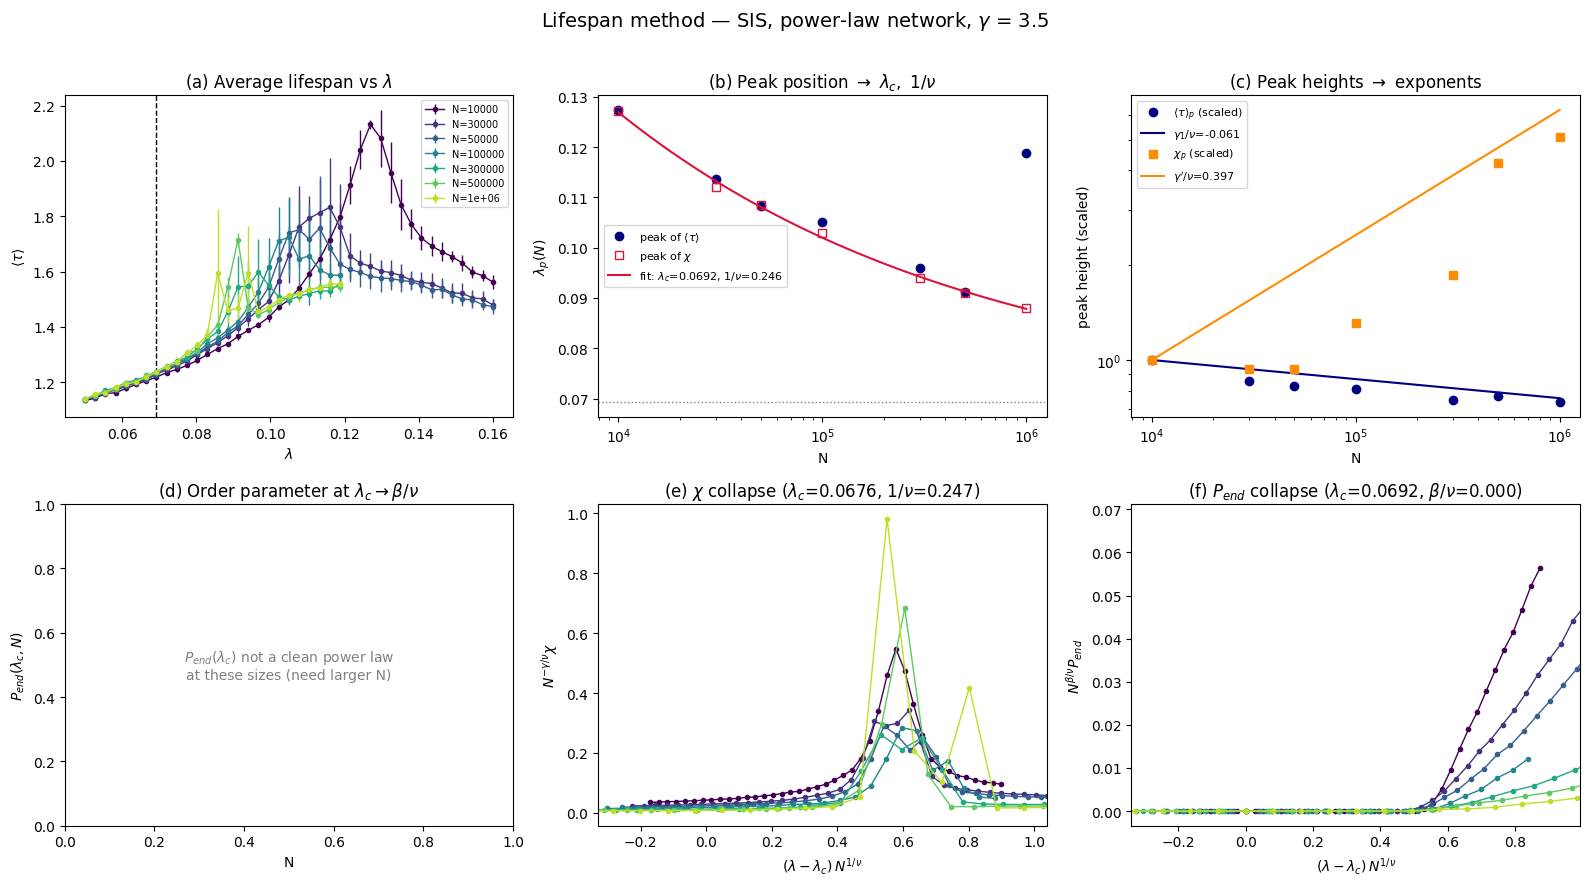

gamma=3.5: lambda_c=0.0692 1/nu=0.246 gamma1/nu=-0.061 gammachi/nu=0.397 beta/nu=nan (tau2=True)


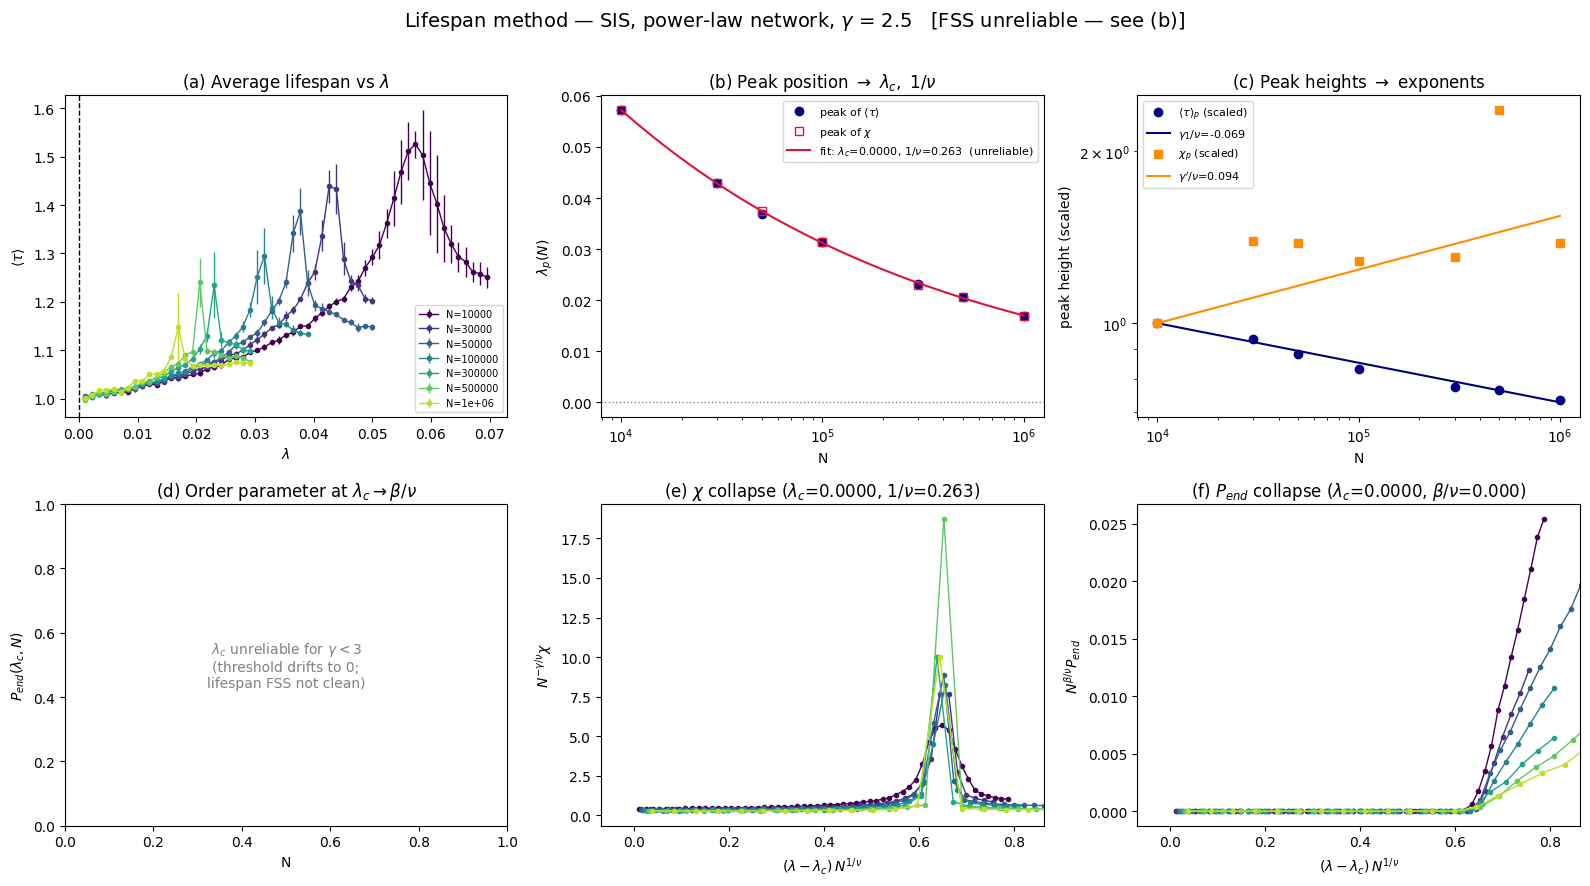

gamma=2.5: lambda_c=0.0000 1/nu=0.263 gamma1/nu=-0.069 gammachi/nu=0.094 beta/nu=nan (tau2=True)


In [4]:
for g in GAMMAS:
    if len(AVAIL[g]) < 2: continue
    fig, info = la.make_panels(RESULTS_DIR, gamma=g)
    fig.savefig(os.path.join(FIG_DIR, f'panels_g{g}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"gamma={g}: lambda_c={info['lambda_c']:.4f} 1/nu={info['inv_nu']:.3f} "
          f"gamma1/nu={info['gamma1_over_nu']:.3f} gammachi/nu={info['gammachi_over_nu']:.3f} "
          f"beta/nu={info['beta_over_nu']:.3f} (tau2={info['has_tau2']})")

## 4. Tabla resumen

In [5]:
print(f"{'gamma':>6} {'lambda_c':>10} {'1/nu':>8} {'gamma1/nu':>10} {'beta/nu':>9}")
for g, s in summaries.items():
    print(f"{g:>6} {s['lambda_c']:>10.5f} {s['inv_nu']:>8.4f} "
          f"{s['gamma1_over_nu']:>10.4f} {s['beta_over_nu']:>9.4f}")

 gamma   lambda_c     1/nu  gamma1/nu   beta/nu
   3.5    0.07839   0.2872    -0.0634       nan
   2.5    0.00000   0.2630    -0.0694       nan


gamma=3.5: lambda_c=0.0692 1/nu=0.246 beta/nu=0.720 cost=0.01025283836241947 (tamanos con senal=7)
gamma=2.5: lambda_c=0.0000 1/nu=0.263 beta/nu=0.438 cost=0.0035641987998581877 (tamanos con senal=7)


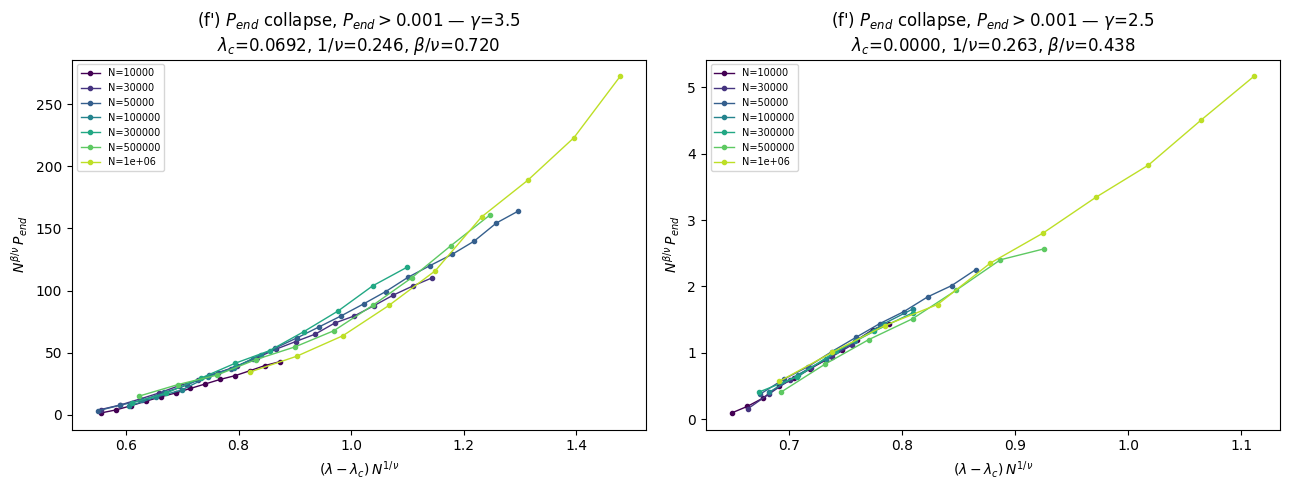

In [6]:
# === Panel (f) rescatado: colapso de P_end sobre la region P_end > 0 ===
import numpy as np, os
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import lifespan_analysis as la

PMIN  = 1e-3     # solo puntos con P_end por encima de este umbral (evita la zona de ceros)
NGRID = 40       # malla comun para medir la calidad del colapso

def _pend_cost(bnu, data, lc, inv_nu, pmin=PMIN, ngrid=NGRID):
    xs, ys = [], []
    for d in data:
        lam, pe, N = np.asarray(d["lam"]), np.asarray(d["P_end"]), d["N"]
        m = pe > pmin
        if m.sum() < 3:
            continue
        x = (lam[m] - lc) * N**inv_nu
        y = pe[m] * N**bnu
        o = np.argsort(x)
        xs.append(x[o]); ys.append(y[o])
    if len(xs) < 2:
        return 1e9
    xmin = max(x[0] for x in xs); xmax = min(x[-1] for x in xs)
    if xmax <= xmin:
        return 1e9
    grid = np.linspace(xmin, xmax, ngrid)
    M = np.array([np.interp(grid, x, y) for x, y in zip(xs, ys)])
    denom = np.abs(M.mean(axis=0)) + 1e-12
    return float(np.mean(M.var(axis=0) / denom**2))

def pend_collapse(results_dir, gamma, sizes=None, ax=None):
    data = la.load_all(results_dir, gamma, sizes=sizes)
    Ns = np.array([d["N"] for d in data], float)
    # lambda_c, 1/nu del pico de chi (mismo localizador que make_panels)
    pk = [la.robust_peak(d["lam"], d["chi"]) for d in data]
    lam_pc = np.array([p[0] for p in pk]); ok = np.array([p[2] for p in pk])
    fit = la.fit_peak_position(Ns, lam_pc, weights=np.where(ok, 1.0, 0.25))
    lc, inv_nu = fit["lambda_c"], fit["inv_nu"]
    # cuantos tamanos tienen senal (P_end>PMIN)
    nsig = sum((np.asarray(d["P_end"]) > PMIN).sum() >= 3 for d in data)
    if nsig >= 2:
        r = minimize_scalar(_pend_cost, bounds=(0.0, 3.0),
                            args=(data, lc, inv_nu), method="bounded")
        bnu, cost = float(r.x), float(r.fun)
    else:
        bnu, cost = 0.0, np.nan   # no hay suficiente senal para ajustar beta/nu

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4.5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(data)))
    for d, c in zip(data, colors):
        lam, pe, N = np.asarray(d["lam"]), np.asarray(d["P_end"]), d["N"]
        m = pe > PMIN
        if m.sum() < 1:
            continue
        ax.plot((lam[m] - lc) * N**inv_nu, pe[m] * N**bnu,
                "-o", ms=3, lw=1, color=c, label=f"N={N:g}")
    ax.set_xlabel(r"$(\lambda-\lambda_c)\,N^{1/\nu}$")
    ax.set_ylabel(r"$N^{\beta/\nu}\,P_{end}$")
    tag = "" if nsig >= 2 else "  [poca senal]"
    ax.set_title(rf"(f') $P_{{end}}$ collapse, $P_{{end}}>${PMIN:g} — $\gamma$={gamma}{tag}"
                 + f"\n$\\lambda_c$={lc:.4f}, 1/$\\nu$={inv_nu:.3f}, $\\beta/\\nu$={bnu:.3f}")
    ax.legend(fontsize=7)
    return dict(lambda_c=lc, inv_nu=inv_nu, beta_nu=bnu, cost=cost, nsig=nsig)

# --- ejecutar para ambos gammas ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, g in zip(np.atleast_1d(axes), GAMMAS):
    if len(AVAIL[g]) < 2:
        ax.set_visible(False); continue
    r = pend_collapse(RESULTS_DIR, gamma=g, ax=ax)
    print(f"gamma={g}: lambda_c={r['lambda_c']:.4f} 1/nu={r['inv_nu']:.3f} "
          f"beta/nu={r['beta_nu']:.3f} cost={r['cost']} (tamanos con senal={r['nsig']})")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "pend_collapse_pos.png"), dpi=150, bbox_inches="tight")
plt.show()

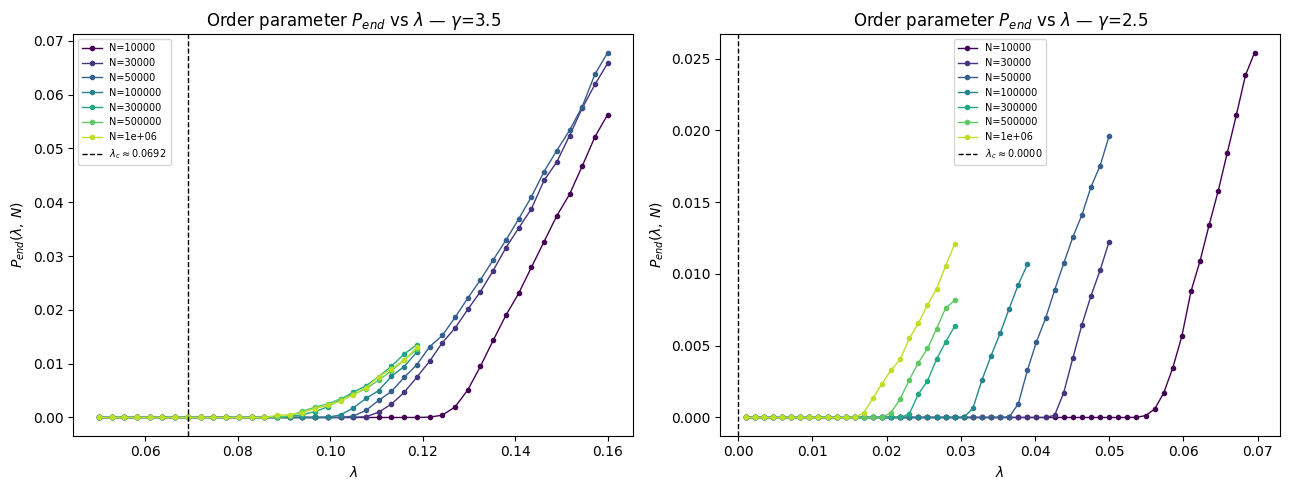

In [7]:
# === Figura de P_end(lambda, N) — parametro de orden del metodo del lifespan ===
import numpy as np, os
import matplotlib.pyplot as plt
import lifespan_analysis as la

def pend_vs_lambda(results_dir, gamma, sizes=None, ax=None):
    data = la.load_all(results_dir, gamma, sizes=sizes)
    Ns = np.array([d["N"] for d in data], float)
    # lambda_c del pico de chi (solo para la linea vertical de referencia)
    pk = [la.robust_peak(d["lam"], d["chi"]) for d in data]
    lam_pc = np.array([p[0] for p in pk]); ok = np.array([p[2] for p in pk])
    fit = la.fit_peak_position(Ns, lam_pc, weights=np.where(ok, 1.0, 0.25))
    lc = fit["lambda_c"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4.5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(data)))
    for d, c in zip(data, colors):
        ax.plot(d["lam"], d["P_end"], "-o", ms=3, lw=1, color=c, label=f"N={d['N']:g}")
    ax.axvline(lc, ls="--", c="k", lw=1, label=f"$\\lambda_c\\approx${lc:.4f}")
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$P_{end}(\lambda,\,N)$")
    ax.set_title(rf"Order parameter $P_{{end}}$ vs $\lambda$ — $\gamma$={gamma}")
    ax.legend(fontsize=7)
    return lc

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, g in zip(np.atleast_1d(axes), GAMMAS):
    if len(AVAIL[g]) < 2:
        ax.set_visible(False); continue
    pend_vs_lambda(RESULTS_DIR, gamma=g, ax=ax)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "Pend_vs_lambda.png"), dpi=150, bbox_inches="tight")
plt.show()

gamma=3.5: beta/nu=0.504 reliable=True
gamma=2.5: beta/nu=0.320 reliable=False


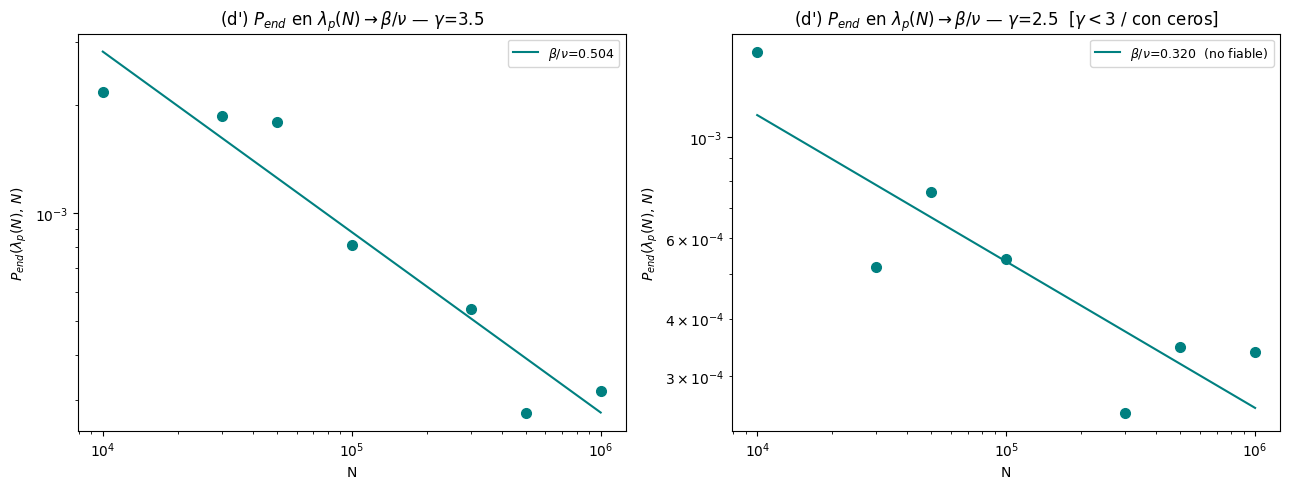

In [8]:
# === Panel (d) rescatado: beta/nu desde P_end en el punto pseudocritico lambda_p(N) ===
import numpy as np, os
import matplotlib.pyplot as plt
import lifespan_analysis as la

def pend_at_pseudocritical(results_dir, gamma, sizes=None, ax=None):
    data = la.load_all(results_dir, gamma, sizes=sizes)
    Ns = np.array([d["N"] for d in data], float)
    # punto pseudocritico de cada tamano = pico de chi (mejor localizador que <tau>)
    lam_p = np.array([la.robust_peak(d["lam"], d["chi"])[0] for d in data])
    # P_end evaluado ahi
    pend = np.array([np.interp(lp, d["lam"], d["P_end"]) for d, lp in zip(data, lam_p)])
    # ajuste log-log (solo usa puntos con P_end>0)
    slope, b = la.fit_loglog_slope(Ns, pend)
    beta_nu = -slope if np.isfinite(slope) else np.nan
    reliable = (gamma >= 3.0) and np.all(pend > 0) and np.isfinite(beta_nu)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4.5))
    m = pend > 0
    ax.loglog(Ns[m], pend[m], "o", color="teal", ms=7)
    if np.isfinite(beta_nu) and m.sum() >= 2:
        xx = np.array([Ns[m].min(), Ns[m].max()])
        ax.loglog(xx, np.exp(b) * xx**slope, "-", color="teal",
                  label=rf"$\beta/\nu$={beta_nu:.3f}" + ("" if reliable else "  (no fiable)"))
    ax.set_xlabel("N")
    ax.set_ylabel(r"$P_{end}(\lambda_p(N),\,N)$")
    tag = "" if reliable else r"  [$\gamma<3$ / con ceros]"
    ax.set_title(rf"(d') $P_{{end}}$ en $\lambda_p(N)\to\beta/\nu$ — $\gamma$={gamma}{tag}")
    ax.legend(fontsize=9)
    return dict(beta_nu=beta_nu, reliable=reliable, lam_p=lam_p, pend=pend)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, g in zip(np.atleast_1d(axes), GAMMAS):
    if len(AVAIL[g]) < 2:
        ax.set_visible(False); continue
    r = pend_at_pseudocritical(RESULTS_DIR, gamma=g, ax=ax)
    print(f"gamma={g}: beta/nu={r['beta_nu']:.3f} reliable={r['reliable']}")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "Pend_at_lc.png"), dpi=150, bbox_inches="tight")
plt.show()